# Libraries

In [27]:
import time
import joblib
import pandas as pd
from functions import *

# Run g function

In [28]:
r_s_realization = np.array([[5, 2]])
n_latent_samples = 1000
times = list(np.linspace(0, 100, 100))
bds = []

In [29]:
for i in times:
    # Original function evaluation    
    start_counter_g = time.perf_counter()
    _, df = state_limit_function_time(r_s_realization, n_latent_samples=n_latent_samples, t=i)
    end_counter_g = time.perf_counter()
    g_list = df[0]['g'].to_list()

    # MLP metamodel evaluation
    start_counter_pce = time.perf_counter()
    mlp_i = joblib.load(r'C:\git-projetos\2024-1_victor_hugo_renata_maria\toy_problem\ai_model\ann_model_lambda.joblib')
    x = pd.DataFrame({'R': list(r_s_realization[:,0]), 'S': list(r_s_realization[:,1]), 'Time': [i]})
    lambdass = mlp_i.predict(x)
    lambda_1 = lambdass[:, 0][0]
    lambda_2 = lambdass[:, 1][0]
    lambda_3 = 0.10
    lambda_4 = 0.10
    lambdass = [lambda_1, lambda_2, lambda_3, lambda_4]
    glam_g_list = glam_data_generator(lambdass, n_points=n_latent_samples)
    end_counter_pce = time.perf_counter()
    bd_obs = {"time": [i] * len(g_list), "g_obs": g_list, "g_emulator": glam_g_list, "elapsed time original": [end_counter_g - start_counter_g] * len(g_list), "elapsed time emulator": [end_counter_pce - start_counter_pce] * len(glam_g_list)}
    aux  = pd.DataFrame(bd_obs)
    bds.append(aux)

In [30]:
bds = pd.concat(bds, ignore_index=True)
bds

,time,g_obs,g_emulator,elapsed time original,elapsed time emulator
0,0.0,3.217987,2.178872,0.528906,0.011419
1,0.0,2.858064,2.237428,0.528906,0.011419
2,0.0,2.756425,2.273683,0.528906,0.011419
3,0.0,2.793245,2.300359,0.528906,0.011419
4,0.0,2.968165,2.321620,0.528906,0.011419
...,...,...,...,...,...
99995,100.0,-0.507267,-0.013098,0.717188,0.007773
99996,100.0,-0.684647,0.005089,0.717188,0.007773
99997,100.0,-0.293765,0.027909,0.717188,0.007773
99998,100.0,-0.668994,0.058923,0.717188,0.007773


In [31]:
bds.describe()

,time,g_obs,g_emulator,elapsed time original,elapsed time emulator
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.000000,1.252002,1.219899,0.676617,0.010231
std,29.157792,1.043758,1.097351,0.320967,0.005218
min,0.000000,-1.366414,-1.277094,0.312309,0.004434
25%,25.000000,0.364720,0.274879,0.463989,0.006526
50%,50.000000,1.248959,1.228490,0.556099,0.008755
75%,75.000000,2.135066,2.136667,0.777608,0.012574
max,100.000000,3.858860,3.842225,1.705149,0.030542


# Elapsed time analysis for g_obs

In [32]:
time_elapsed = bds['elapsed time original'].unique()
time_elapsed.sum()

67.66168610000659

# Elapsed time analysis for pce

In [33]:
time_elapsed_pce = bds['elapsed time emulator'].unique()
time_elapsed_pce.sum()

1.0230834999974832

# Charts - Compare real g and emulated g

In [34]:
df_summary = (
    bds
    .groupby("time")
    .agg(
        g_obs_mean=("g_obs", "mean"),
        g_obs_p05=("g_obs", lambda x: x.quantile(0.05)),
        g_obs_p95=("g_obs", lambda x: x.quantile(0.95)),
        g_pce_mean=("g_pce", "mean"),
        g_pce_p05=("g_pce", lambda x: x.quantile(0.05)),
        g_pce_p95=("g_pce", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)


KeyError: "Column(s) ['g_pce'] do not exist"

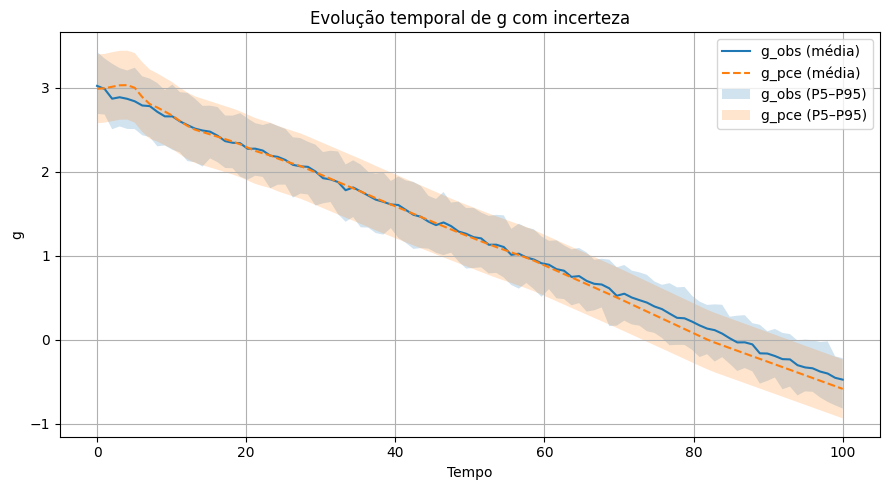

In [ ]:
plt.figure(figsize=(9, 5))

# Médias
plt.plot(df_summary["time"], df_summary["g_obs_mean"], label="g_obs (média)")
plt.plot(df_summary["time"], df_summary["g_pce_mean"], label="g_pce (média)", linestyle="--")

# Bandas de incerteza
plt.fill_between(
    df_summary["time"],
    df_summary["g_obs_p05"],
    df_summary["g_obs_p95"],
    alpha=0.2,
    label="g_obs (P5–P95)"
)

plt.fill_between(
    df_summary["time"],
    df_summary["g_pce_p05"],
    df_summary["g_pce_p95"],
    alpha=0.2,
    label="g_pce (P5–P95)"
)

plt.xlabel("Tempo")
plt.ylabel("g")
plt.title("Evolução temporal de g com incerteza")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Remaining Useful Life (RUL) estimation

In [ ]:
g_ti = g_value_for_ti(bds, t_i)
# time_bellow_threshold = g_ti[g_ti['g_obs'] <= 0]['time']
time_to_threshold = time_bellow_threshold(bds, g_treshold)
rul_data = rul(bds, t_i, g_treshold)

# RUL charts